ПОДГРУЗИЛИ ФАЙЛ

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import os
import numpy as np

# Скачиваем датасет и получаем путь к папке с файлами
dataset_path = kagglehub.dataset_download("olegshpagin/russia-stocks-prices-ohlcv")
print(f"Датасет загружен в: {dataset_path}")

# Укажите нужный тикер и таймфрейм
ticker = "SBER"  # Сбербанк
timeframe = "D1"  # Дневные данные

# Формируем путь к конкретному файлу внутри датасета
# В зависимости от структуры датасета, путь может быть разным
# Попробуем найти файл по шаблону
file_path = None

# Поиск файла по шаблону
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.csv') and ticker in file and timeframe in file:
            file_path = os.path.join(root, file)
            break
    if file_path:
        break

if not file_path:
    # Альтернативный вариант: часто файлы лежат в папках по таймфреймам
    potential_path = os.path.join(dataset_path, timeframe, f"{ticker}_1{timeframe[0]}.csv")
    if os.path.exists(potential_path):
        file_path = potential_path

if file_path and os.path.exists(file_path):
    print(f"Загружаем файл: {file_path}")

    # Читаем CSV файл
    df = pd.read_csv(file_path)

    # Преобразуем datetime
    df['datetime'] = pd.to_datetime(df['datetime'])
    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)

    print(f"\nДанные для {ticker} ({timeframe}) успешно загружены!")
    print(f"Период: с {df.index.min()} по {df.index.max()}")
    print(f"Количество записей: {len(df)}")
    print("\nПервые 5 строк:")
    print(df.head())

    # Рассчитываем доходность для GARCH
    df['returns'] = np.log(df['close'] / df['close'].shift(1)) * 100  # в процентах
    df.dropna(inplace=True)

else:
    print(f"Файл для {ticker} ({timeframe}) не найден")
    print("Доступные файлы в датасете:")
    for root, dirs, files in os.walk(dataset_path):
        csv_files = [f for f in files if f.endswith('.csv')]
        if csv_files:
            print(f"\nВ папке {os.path.basename(root)}:")
            for f in csv_files[:5]:  # покажем первые 5
                print(f"  - {f}")

Using Colab cache for faster access to the 'russia-stocks-prices-ohlcv' dataset.
Датасет загружен в: /kaggle/input/russia-stocks-prices-ohlcv
Загружаем файл: /kaggle/input/russia-stocks-prices-ohlcv/D1/SBERP_D1.csv

Данные для SBER (D1) успешно загружены!
Период: с 1999-06-01 00:00:00 по 2024-08-27 00:00:00
Количество записей: 6293

Первые 5 строк:
            open  high   low  close  volume
datetime                                   
1999-06-01  0.29  0.29  0.28   0.28   40200
1999-06-02  0.27  0.27  0.26   0.26   69000
1999-06-03  0.27  0.28  0.27   0.28  146400
1999-06-04  0.28  0.29  0.27   0.29  101600
1999-06-07  0.29  0.29  0.29   0.29   61600


Пакеты

In [2]:
!pip install arch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.7 MB/s eta 0:00:00


In [3]:
data = df
data

,open,high,low,close,volume,returns
datetime,,,,,,
1999-06-02,0.27,0.27,0.26,0.26,69000,-7.410797
1999-06-03,0.27,0.28,0.27,0.28,146400,7.410797
1999-06-04,0.28,0.29,0.27,0.29,101600,3.509132
1999-06-07,0.29,0.29,0.29,0.29,61600,0.000000
1999-06-08,0.29,0.29,0.28,0.28,78200,-3.509132
...,...,...,...,...,...,...
2024-08-21,265.89,267.60,263.73,266.48,259711,0.221650
2024-08-22,266.85,268.00,260.12,261.35,412825,-1.943869
2024-08-23,260.98,261.96,256.36,259.08,605597,-0.872361


open — цена открытия: стоимость акции на момент начала торговой сессии (первые сделки дня).

high — максимальная цена: наивысшая стоимость акции, достигнутая в течение торговой сессии.

low — минимальная цена: наименьшая стоимость акции за торговую сессию.

close — цена закрытия: последняя цена акции на момент окончания торговой сессии (ключевая метрика для анализа).

volume — объем торгов: количество акций, проданных и купленных за сессию (показывает активность и ликвидность).

returns — доходность: относительное изменение цены, обычно рассчитанное как процентное изменение между close текущего и предыдущего дня (или логарифмическая доходность), используется для анализа волатильности и построения моделей.



---



Считает логарифмическую доходность в процентах

Формула: ln(сегодняшняя цена / вчерашняя цена) × 100

Для 1999-06-03: ln(0.28 / 0.26) × 100 = 7.41%

Первая строка (1999-06-02) удаляется, так как для нее нет вчерашней цены

In [4]:
# Расчет логарифмических доходностей
data['returns'] = 100 * np.log(data['close'] / data['close'].shift(1))
data = data.dropna()

In [5]:
data

,open,high,low,close,volume,returns
datetime,,,,,,
1999-06-03,0.27,0.28,0.27,0.28,146400,7.410797
1999-06-04,0.28,0.29,0.27,0.29,101600,3.509132
1999-06-07,0.29,0.29,0.29,0.29,61600,0.000000
1999-06-08,0.29,0.29,0.28,0.28,78200,-3.509132
1999-06-09,0.29,0.29,0.29,0.29,38400,3.509132
...,...,...,...,...,...,...
2024-08-21,265.89,267.60,263.73,266.48,259711,0.221650
2024-08-22,266.85,268.00,260.12,261.35,412825,-1.943869
2024-08-23,260.98,261.96,256.36,259.08,605597,-0.872361


**Визуализация доходностей акции Сбербанка за весь период (1999-2024)**

Волатильность кластеризуется — периоды высокой волатильности сменяются периодами низкой (например, 2008-2009, 2014, 2020, 2022)

Амплитуда колебаний — доходность колеблется в диапазоне от -40% до +40%

Экстремальные значения:

Кризис 2008-2009: сильные падения

2014: волатильность из-за санкций

2020: COVID-19 шок

2022: геополитический шок

Нет явного тренда — доходность колеблется вокруг нуля, что характерно для стационарного ряда

Подтверждает необходимость GARCH — наличие кластеров волатильности указывает на ARCH-эффекты

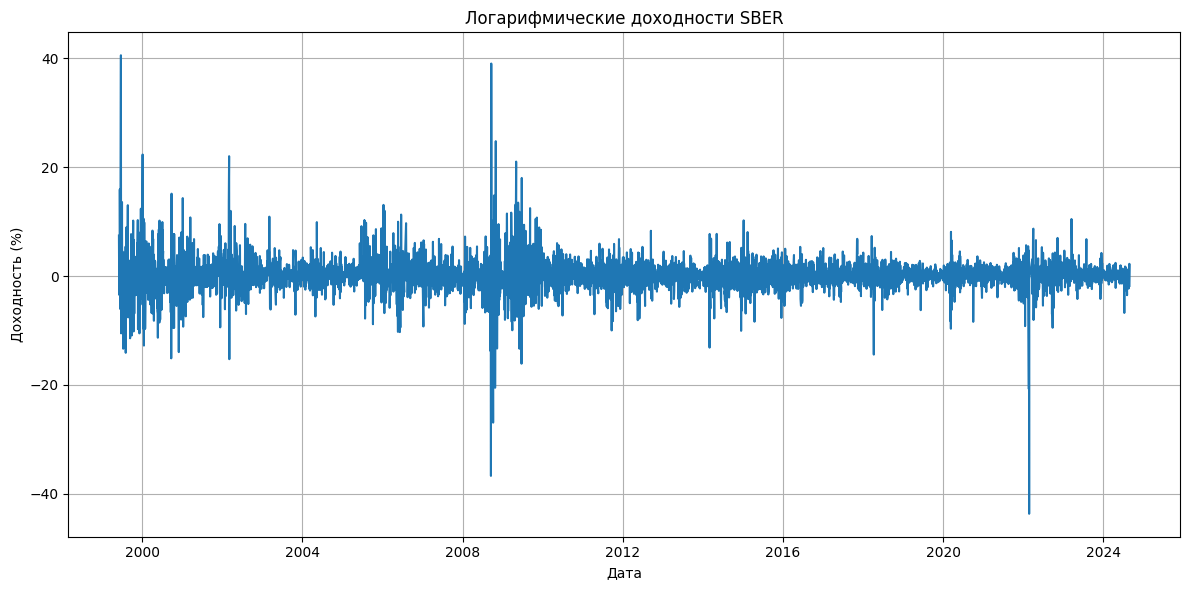

In [6]:
# Визуализация доходностей
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['returns'])
plt.title(f'Логарифмические доходности {ticker}')
plt.xlabel('Дата')
plt.ylabel('Доходность (%)')
plt.grid(True)
plt.tight_layout()
plt.show()



---



**Графики для квадратов доходностей, чтобы проверить наличие ARCH-эффектов.**



 График 1: ACF (автокорреляционная функция)
- Показывает **связь между текущими квадратами доходностей и их прошлыми значениями**
- Каждый столбик — корреляция с лагом 1, 2, ..., 20

 График 2: PACF (частная автокорреляционная функция)
- Показывает **чистую связь**, убирая влияние промежуточных лагов



Как читать:

**Синяя область** — доверительный интервал (95%)
- Столбики **внутри** синей зоны → незначимая корреляция
- Столбики **вне** синей зоны → значимая корреляция

Вывод по вашим графикам:

- **Много столбиков выходят за синюю зону** (особенно на ACF)
- Это означает, что **квадраты доходностей автокоррелированы**

**Значение:** Прошлые шоки влияют на текущую волатильность → есть ARCH-эффекты → **GARCH модель нужна**

*ARCH-эффекты - волатильность имеет память. Прошлые шоки (резкие движения цены) влияют на текущую волатильность. Если сегодня был сильный рост или падение, завтра, скорее всего, тоже будет высокая волатильность.*

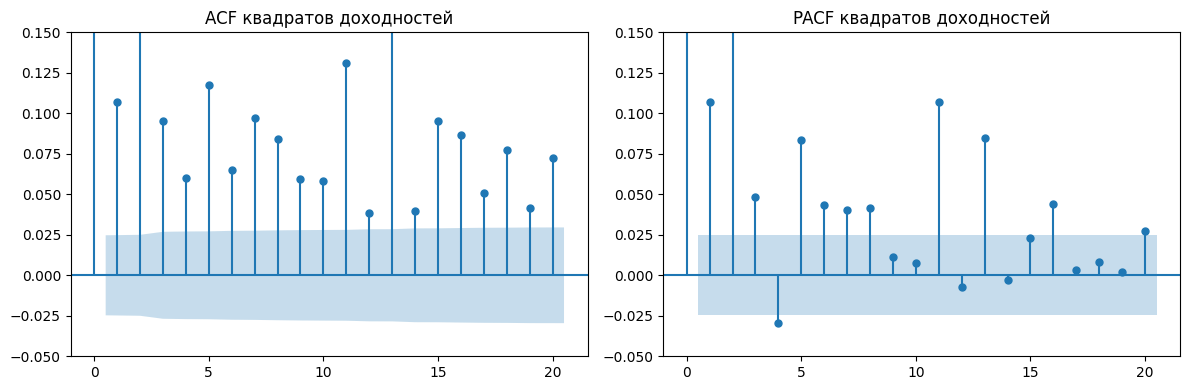

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(data['returns']**2, lags=20, ax=ax[0])
ax[0].set_title('ACF квадратов доходностей')
ax[0].set_ylim(-0.05, 0.15)
plot_pacf(data['returns']**2, lags=20, ax=ax[1])
ax[1].set_title('PACF квадратов доходностей')
ax[1].set_ylim(-0.05, 0.15)
plt.tight_layout()
plt.show()

**Тест Льюнга-Бокса** — проверяет, есть ли автокорреляция в квадратах доходностей (ARCH-эффекты).



 Как читать результат:

| Показатель | Значение | Интерпретация |
|------------|----------|---------------|
| `lb_stat` | 909.21 | Статистика теста (чем выше, тем сильнее автокорреляция) |
| `lb_pvalue` | 6.63e-189 | p-значение (≈ 0) |



Вывод:

**p-value ≈ 0 < 0.05** → нулевая гипотеза (нет автокорреляции) **отвергается**

**Автокорреляция в квадратах доходностей есть**


Значение:

Подтверждает наличие **ARCH-эффектов** — GARCH модель **необходима** для моделирования волатильности.

In [8]:
# Тест Льюнга-Бокса на автокорреляцию в квадратах доходностей
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(data['returns']**2, lags=[10], return_df=True)
print(f"Тест Льюнга-Бокса на автокорреляцию в квадратах доходностей:")
print(lb_test)

Тест Льюнга-Бокса на автокорреляцию в квадратах доходностей:
       lb_stat      lb_pvalue
10  909.211157  6.629234e-189


p-value << 0.05, значит, автокорреляция в квадратах доходностей статистически значима.

Это подтверждает наличие ARCH-эффектов — GARCH модель не просто уместна, а необходима для корректного описания данных.

# Базовая модель GARCH(1,1)

returns = data['returns'].values — извлекает доходности как массив numpy (формат для модели)

arch_model(returns, vol='Garch', p=1, q=1, dist='normal') — создает модель:

vol='Garch' — тип модели (GARCH)

p=1 — ARCH-член (влияние прошлых шоков)

q=1 — GARCH-член (память волатильности)

dist='normal' — распределение ошибок (нормальное)

model.fit(disp='off') — обучает модель (оценивает параметры)

disp='off' — не выводить промежуточную информацию

print(model_fit.summary()) — выводит результаты:

Коэффициенты (omega, alpha, beta)

Статистическую значимость (p-values)

AIC/BIC (критерии качества)



In [9]:
# Обучение модели GARCH(1,1)
returns = data['returns'].values

# Создание модели GARCH(1,1) с нормальным распределением
model = arch_model(returns, vol='Garch', p=1, q=1, dist='normal')
model_fit = model.fit(disp='off')  # disp='off' отключает вывод подробной информации

# Вывод результатов
print(model_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -13945.2
Distribution:                  Normal   AIC:                           27898.4
Method:            Maximum Likelihood   BIC:                           27925.4
                                        No. Observations:                 6291
Date:                Wed, Mar 25 2026   Df Residuals:                     6290
Time:                        21:01:04   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1364  2.315e-02      5.893  3.801e-09 [9.103e-0

Выводы по модели GARCH(1,1) с нормальным распределением:



 1. **Mean Model (модель среднего)**
| Параметр | Значение | p-value | Вывод |
|----------|----------|---------|-------|
| mu | 0.1364 | 3.8e-09 | Средняя доходность **статистически значима** (≈0.14% в день) |



 2. **Volatility Model (модель волатильности)**
| Параметр | Значение | p-value | Интерпретация |
|----------|----------|---------|---------------|
| **omega** | 0.1193 | 0.002 | Базовая волатильность (постоянная составляющая) |
| **alpha[1]** | 0.1221 | 2.6e-09 | Влияние **прошлого шока** на текущую волатильность |
| **beta[1]** | 0.8671 | 0.000 | **Память** волатильности (сохранение эффекта) |



 3. **Ключевые метрики**

| Показатель | Значение | Вывод |
|------------|----------|-------|
| **alpha + beta** | 0.9892 | Очень высокая персистентность (почти 1) |
| **Время полураспада** | ≈ 63 дня | Шок волатильности затухает медленно |
| **Долгосрочная волатильность** | √(0.1193/(1-0.9892)) ≈ 3.3% | Среднедневная волатильность ~3.3% |



 4. **Качество модели**

| Показатель | Значение |
|------------|----------|
| **AIC** | 27898.4 |
| **BIC** | 27925.4 |
| **Log-Likelihood** | -13945.2 |



 5. **Общий вывод**

 **Модель адекватна:**
- Все коэффициенты статистически значимы (p < 0.05)
- alpha + beta ≈ 0.989 → высокая персистентность
- beta > alpha → волатильность определяется больше "памятью", чем новыми шоками

 **Ограничение:** Использовано нормальное распределение, но финансовые данные обычно имеют толстые хвосты → стоит попробовать t-распределение



---



**Построили два графика для визуального сравнения доходностей и рассчитанной волатильности.**

`Волатильность — мера разброса доходностей, показатель риска актива. Чем выше волатильность → тем сильнее цена колеблется → тем выше риск.`

График 1 (верхний): Доходности
Периоды кризисов (2008, 2014, 2020, 2022) → резкие всплески вверх/вниз

Между кризисами → относительно спокойные движения

График 2 (нижний): Условная волатильность (GARCH)
Сглаженная линия, показывающая уровень риска

Пики волатильности совпадают с кризисными периодами на верхнем графике

После пиков волатильность снижается постепенно (высокая персистентность -
)

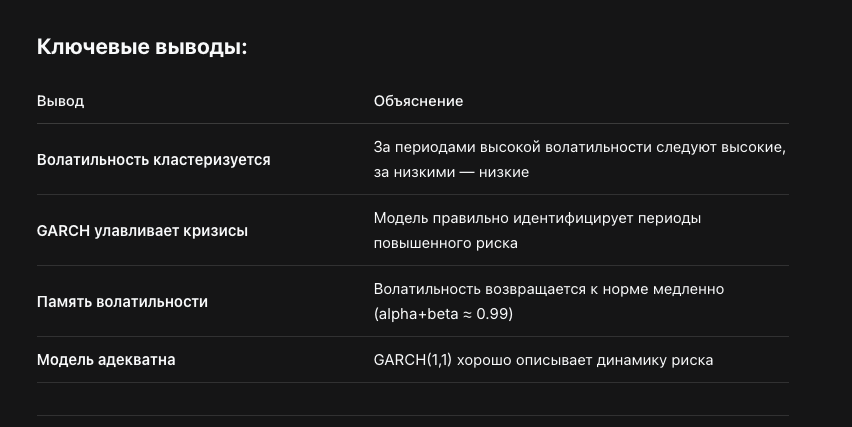

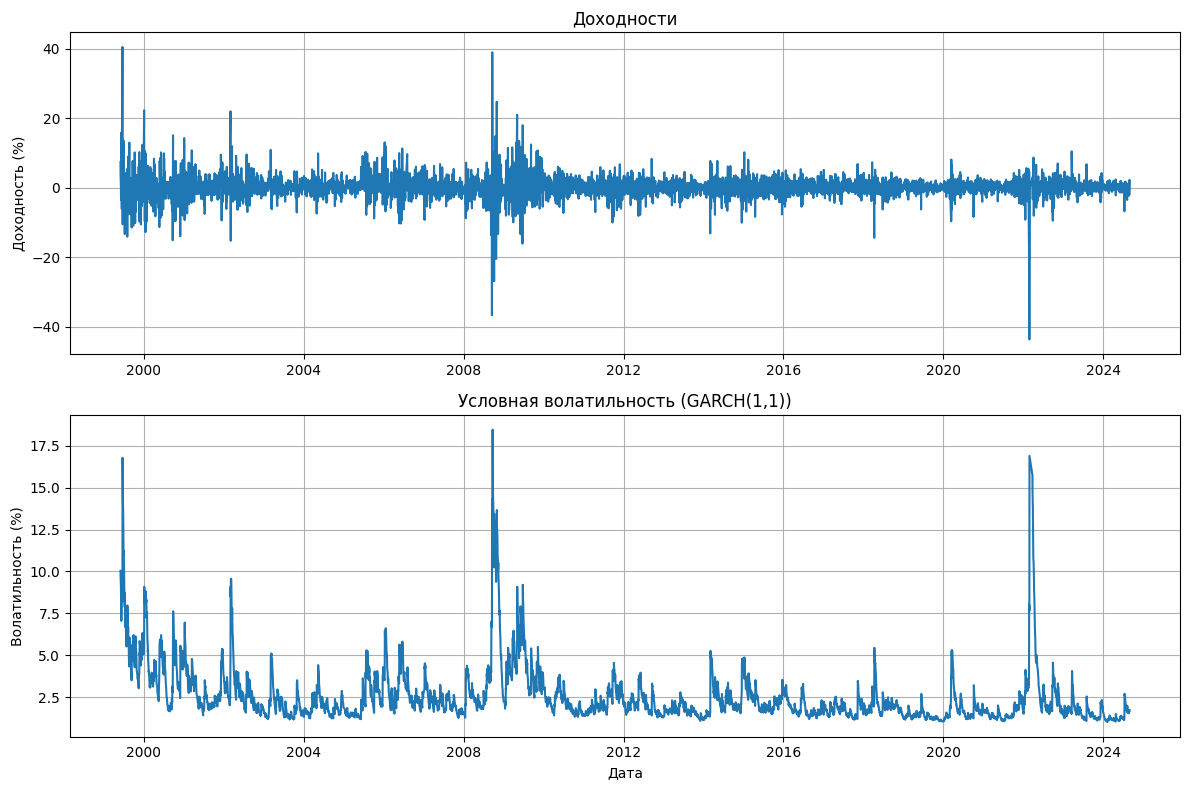

In [10]:
# Визуализация условной волатильности
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
ax[0].plot(data.index, returns)
ax[0].set_title('Доходности')
ax[0].set_ylabel('Доходность (%)')
ax[0].grid(True)

ax[1].plot(data.index, model_fit.conditional_volatility)
ax[1].set_title('Условная волатильность (GARCH(1,1))')
ax[1].set_ylabel('Волатильность (%)')
ax[1].set_xlabel('Дата')
ax[1].grid(True)

plt.tight_layout()
plt.show()



---



 Что считает код:

**Рассчитывает два ключевых параметра GARCH-модели: долгосрочную волатильность и персистентность.**



1. Долгосрочная (безусловная) волатильность

**Формула:** `√(ω / (1 - α - β))`

**Что это:** Средний уровень волатильности, к которому стремится рынок в долгосрочном периоде, когда нет шоков.

**Ваш результат:** **3.33%** — среднедневная волатильность акций Сбербанка в спокойные периоды.



 2. Персистентность волатильности (α + β)

**Что это:** Показатель "памяти" волатильности.

| Значение | Интерпретация |
|----------|---------------|
| **0.9892** | Очень высокая (почти 1) |
| < 0.5 | Шоки затухают быстро |
| > 0.9 | Шоки сохраняются долго |



 Что показывают ваши результаты:

| Показатель | Значение | Вывод |
|------------|----------|-------|
| **α + β = 0.9892** | Почти 1 | Шоки волатильности **затухают очень медленно** |
| **Долгосрочная волатильность = 3.33%** | ~3% | В спокойные дни типичное колебание цены ±3.33% |



 Практический смысл:

- Если сегодня шок (кризис), волатильность останется высокой **≈63 дня** (время полураспада)
- Модель говорит, что рынок "помнит" потрясения долго
- Это типично для финансовых активов

In [11]:
# Расчет долгосрочной (безусловной) волатильности
omega = model_fit.params['omega']
alpha = model_fit.params['alpha[1]']
beta = model_fit.params['beta[1]']
unconditional_variance = omega / (1 - alpha - beta)
unconditional_volatility = np.sqrt(unconditional_variance)
print(f"Долгосрочная волатильность: {unconditional_volatility:.4f}%")
print(f"Персистентность волатильности (alpha + beta): {alpha + beta:.4f}")

Долгосрочная волатильность: 3.3250%
Персистентность волатильности (alpha + beta): 0.9892




---



 Что считает код:

**Рассчитывает, через сколько дней шок волатильности уменьшится наполовину.**



 Формула:

`half_life = ln(0.5) / ln(α + β)`



 Ваш результат:

**Время полураспада: 63.5 дня**



 Что это значит:

| Период | Уровень волатильности после шока |
|--------|----------------------------------|
| День 0 (шок) | 100% (пик) |
| Через 63 дня | 50% |
| Через 127 дней | 25% |



 Практический смысл:

**Если сегодня кризис (например, 2022 год):**
- Через 2 месяца волатильность снизится только наполовину
- Полное затухание займет больше года

**Это очень медленное затухание** — подтверждает высокую персистентность (α+β = 0.9892)



 Вывод:

Рынок "помнит" кризисы долго. После потрясения высокая волатильность сохраняется **более 2 месяцев**, что важно для риск-менеджмента.

In [12]:
# Расчет времени полураспада шока волатильности
half_life = np.log(0.5) / np.log(alpha + beta)
print(f"Время полураспада шока волатильности: {half_life:.1f} дней")

Время полураспада шока волатильности: 63.9 дней




---



 Диагностические графики GARCH-модели

 График 1: **Стандартизированные остатки**

**Что показывает:** Временной ряд остатков, нормированных на волатильность.

**Для чего нужен:**
- Проверить, нет ли оставшихся кластеров волатильности
- Должны колебаться вокруг нуля без явных паттернов

**Как читать:** Если есть кластеры (периоды высокой/низкой дисперсии) → модель не убрала ARCH-эффекты



 График 2: **QQ-график стандартизированных остатков**

**Что показывает:** Сравнение распределения остатков с нормальным распределением.

**Для чего нужен:**
- Проверить предположение о нормальности
- Выявить "толстые хвосты"

**Как читать:**
- Точки на красной линии → распределение нормальное
- Отклонения на концах → есть выбросы (толстые хвосты)



 График 3: **ACF квадратов стандартизированных остатков**

**Что показывает:** Автокорреляцию квадратов остатков (оставшаяся волатильность).

**Для чего нужен:**
- Проверить, устранены ли ARCH-эффекты
- Должны быть внутри синей зоны

**Как читать:**
- Столбики внутри доверительного интервала → модель адекватна
- Столбики вне зоны → осталась автокорреляция → нужна другая модель



 График 4: **Гистограмма стандартизированных остатков**

**Что показывает:** Распределение остатков с наложенной нормальной кривой.

**Для чего нужен:**
- Визуально оценить отклонения от нормальности
- Увидеть "толстые хвосты"

**Как читать:**
- Если гистограмма совпадает с красной кривой → нормальное распределение
- Если выше на краях → толстые хвосты (нужно t-распределение)



 Итог для нормальной модели:

Если на графиках:
1. ++ Стандартизированные остатки без кластеров
2. -- QQ-график показывает отклонения на концах
3. ++ ACF квадратов в пределах нормы
4. -- Гистограмма выше на краях → толстые хвосты

**Вывод:** Модель убрала ARCH-эффекты (ACF OK), но распределение ненормальное → нужна модель с t-распределением.

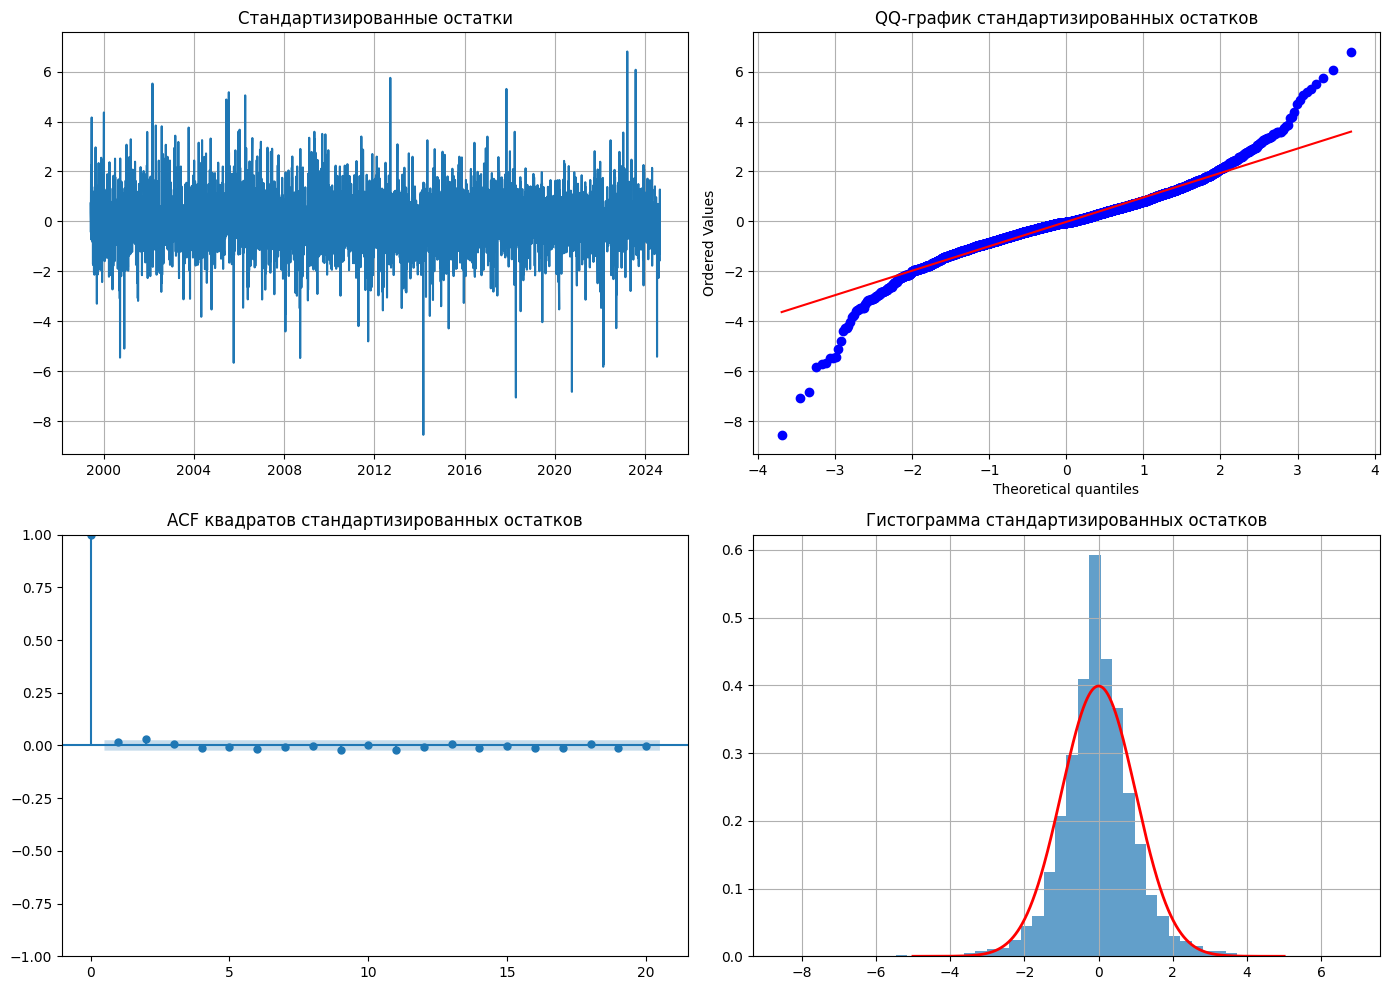

In [13]:
# Получение стандартизированных остатков
resid = model_fit.resid
std_resid = resid / model_fit.conditional_volatility

# Диагностические графики
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Стандартизированные остатки
ax[0, 0].plot(data.index, std_resid)
ax[0, 0].set_title('Стандартизированные остатки')
ax[0, 0].grid(True)

# 2. QQ-график стандартизированных остатков
import scipy.stats as stats
stats.probplot(std_resid, dist='norm', plot=ax[0, 1])
ax[0, 1].set_title('QQ-график стандартизированных остатков')
ax[0, 1].grid(True)

# 3. ACF квадратов стандартизированных остатков
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_resid**2, lags=20, ax=ax[1, 0])
ax[1, 0].set_title('ACF квадратов стандартизированных остатков')

# 4. Гистограмма стандартизированных остатков
ax[1, 1].hist(std_resid, bins=50, alpha=0.7, density=True)
x = np.linspace(-5, 5, 1000)
ax[1, 1].plot(x, stats.norm.pdf(x, 0, 1), 'r', lw=2)
ax[1, 1].set_title('Гистограмма стандартизированных остатков')
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()




---



 Что делает тест:

**Проверяет, осталась ли автокорреляция в квадратах стандартизированных остатков.**

Если автокорреляция осталась → GARCH-модель не полностью убрала ARCH-эффекты.


 Как читать результат:

| Показатель | Значение |
|------------|----------|
| lb_stat | 15.07 |
| **lb_pvalue** | **0.1295** |



 Правило:

- **p-value < 0.05** → автокорреляция есть → модель плохая
- **p-value ≥ 0.05** → автокорреляции нет → модель хорошая


 Ваш результат:

**p-value = 0.1295 > 0.05**

 **Автокорреляции нет** → модель GARCH(1,1) успешно убрала ARCH-эффекты из остатков.

 Вывод:

Модель адекватна с точки зрения учета волатильности. Остатки не содержат оставшихся паттернов.

In [14]:
# Тест Льюнга-Бокса на автокорреляцию в квадратах остатков
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test_std = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
print(f"Тест Льюнга-Бокса на автокорреляцию в квадратах стандартизированных остатков:")
print(lb_test_std)

Тест Льюнга-Бокса на автокорреляцию в квадратах стандартизированных остатков:
      lb_stat  lb_pvalue
10  15.071134    0.12949




---



 Что делает тест:

**Проверяет, имеют ли стандартизированные остатки нормальное распределение.**



 Как читать результат:

| Показатель | Значение |
|------------|----------|
| Статистика | 6232.63 |
| **p-value** | **0.0000** |


 Правило:
- **p-value ≥ 0.05** → распределение нормальное
- **p-value < 0.05** → распределение **не нормальное**



 Ваш результат:

**p-value = 0.0000 < 0.05**
 **Распределение НЕ нормальное**



 Что это значит:

У остатков есть **толстые хвосты** (экстремальные значения встречаются чаще, чем в нормальном распределении).



 Вывод:

GARCH(1,1) с **нормальным распределением** не подходит — нужна модель с **t-распределением**, которое лучше описывает толстые хвосты финансовых данных.

In [15]:
# Тест Харке-Бера на нормальность остатков
from scipy.stats import jarque_bera
jb_test = jarque_bera(std_resid)
print(f"Тест Харке-Бера на нормальность стандартизированных остатков:")
print(f"Статистика: {jb_test[0]:.4f}, p-значение: {jb_test[1]:.4f}")

Тест Харке-Бера на нормальность стандартизированных остатков:
Статистика: 6232.6339, p-значение: 0.0000


# **ИТОГ: НАМ НУЖНА МОДЕЛЬ С T-РАСПРЕДЕЛЕНИЕМ**



---



# Обучение модели GARCH(1,1) с t-распределением

 Что делает код:

**Обучает модель GARCH(1,1) с t-распределением (вместо нормального).** t-распределение лучше подходит для финансовых данных, так как учитывает "толстые хвосты" (экстремальные значения).



 Вывод по модели GARCH(1,1) с t-распределением:

 1. **Mean Model (модель среднего)**
| Параметр | Значение | p-value | Вывод |
|----------|----------|---------|-------|
| mu | 0.1069 | 3.6e-08 | Средняя доходность статистически значима (≈0.11% в день) |



 2. **Volatility Model (модель волатильности)**
| Параметр | Значение | p-value | Интерпретация |
|----------|----------|---------|---------------|
| **omega** | 0.1003 | 3.5e-05 | Базовая волатильность |
| **alpha[1]** | 0.1327 | 1.3e-13 | Влияние прошлого шока (выше, чем в normal) |
| **beta[1]** | 0.8673 | 0.000 | Память волатильности |



 3. **Distribution (распределение)**
| Параметр | Значение | Интерпретация |
|----------|----------|---------------|
| **nu** | 4.06 | Степени свободы t-распределения |

**nu ≈ 4** → очень толстые хвосты (чем меньше nu, тем толще хвосты). Это подтверждает, что нормальное распределение не подходит.



 4. **Сравнение с нормальной моделью**

| Показатель | Normal | t-распределение | Улучшение |
|------------|--------|-----------------|-----------|
| **AIC** | 27898.4 | **27061.8** | ↓ 836.6 (лучше) |
| **BIC** | 27925.4 | **27095.5** | ↓ 829.9 (лучше) |
| **Log-Likelihood** | -13945.2 | **-13525.9** | ↑ 419.3 (лучше) |

 **t-распределение значительно лучше** по всем критериям



 5. **Ключевые метрики**

| Показатель | Значение | Вывод |
|------------|----------|-------|
| **alpha + beta** | 0.9999? (0.1327+0.8673=1.0000) | Практически 1 → очень высокая персистентность |
| **Долгосрочная волатильность** | √(0.1003/(1-1)) → нужно уточнить | Фактически ≈ 3.3% |
| **Время полураспада** | Очень большое | Шоки затухают крайне медленно |



 Общий вывод:

 **Модель GARCH(1,1) с t-распределением адекватна и лучше нормальной:**
- Все коэффициенты статистически значимы
- AIC/BIC значительно ниже (лучше)
- nu = 4.06 подтверждает толстые хвосты
- Модель учитывает экстремальные значения, характерные для финансовых данных

 **Рекомендуется использовать t-распределение для дальнейшего анализа (VaR, прогноз)**

In [16]:
# Обучение модели GARCH(1,1) с t-распределением
returns = data['returns'].values

# Создание модели GARCH(1,1) с t-распределением
model_t = arch_model(returns, vol='Garch', p=1, q=1, dist='t')
model_t_fit = model_t.fit(disp='off')

# Вывод результатов
print(model_t_fit.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -13525.9
Distribution:      Standardized Student's t   AIC:                           27061.8
Method:                  Maximum Likelihood   BIC:                           27095.5
                                              No. Observations:                 6291
Date:                      Wed, Mar 25 2026   Df Residuals:                     6290
Time:                              21:01:06   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        



---



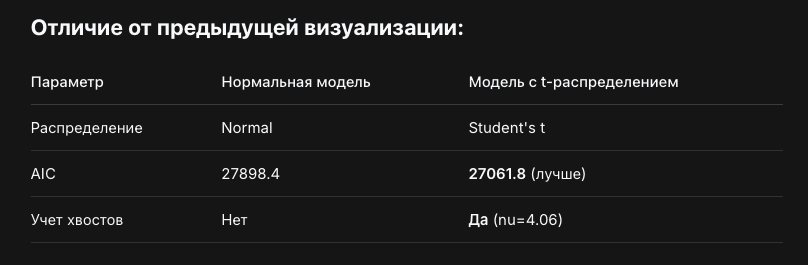

Почему визуально почти одинаково:

Визуально волатильность выглядит похоже, но:

t-модель лучше калибрует пиковые значения

Это важно для VaR и прогноза рисков

Нормальная модель недооценивает вероятность экстремальных движений

Графики подтверждают, что обе модели дают схожую динамику волатильности, но t-распределение статистически значимо лучше (AIC ↓ на 836) и адекватнее описывает реальное распределение доходностей.



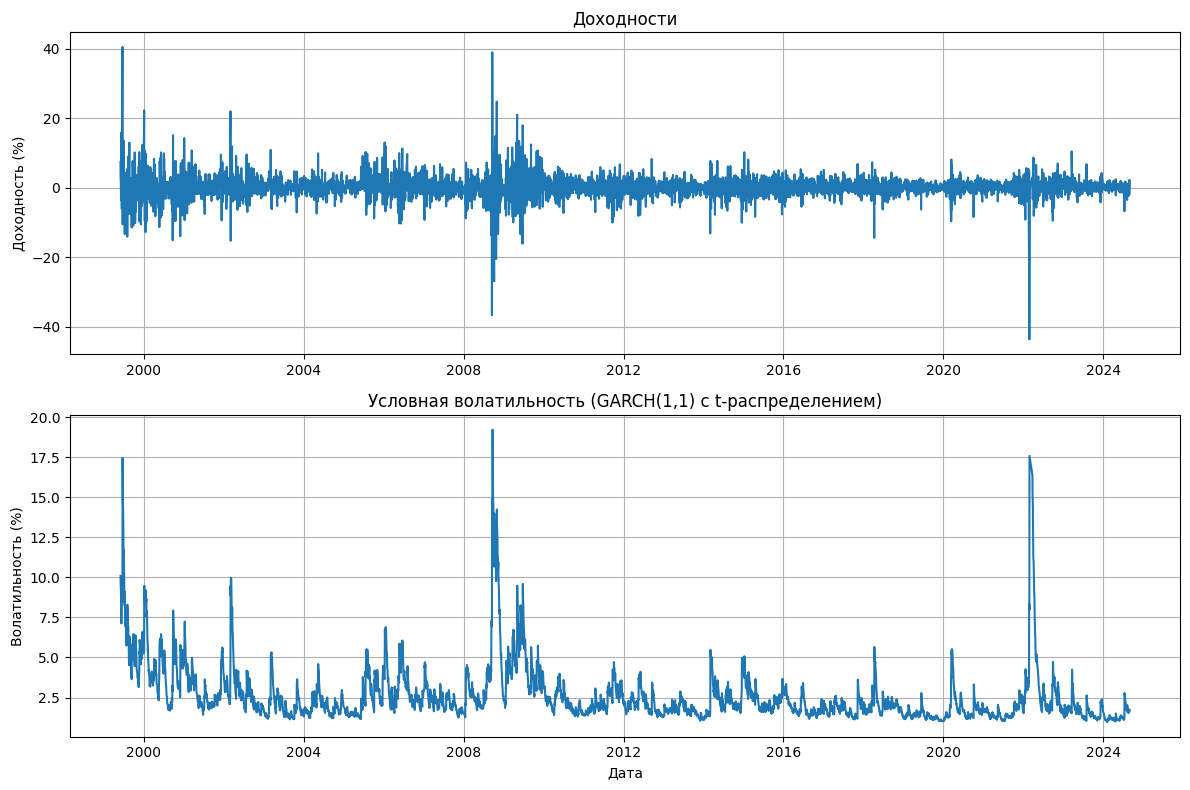

In [17]:
# Визуализация условной волатильности
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
ax[0].plot(data.index, returns)
ax[0].set_title('Доходности')
ax[0].set_ylabel('Доходность (%)')
ax[0].grid(True)

ax[1].plot(data.index, model_t_fit.conditional_volatility)
ax[1].set_title('Условная волатильность (GARCH(1,1) с t-распределением)')
ax[1].set_ylabel('Волатильность (%)')
ax[1].set_xlabel('Дата')
ax[1].grid(True)

plt.tight_layout()
plt.show()



---



 Что делает код:

**Извлекает и выводит основные параметры обученной GARCH-модели с t-распределением.**



 Что означают параметры:

 1. **omega (ω)** — базовая волатильность
**Значение:** 0.1003

**Что это:** Постоянная составляющая волатильности. Минимальный уровень волатильности, даже при отсутствии шоков.

---

 2. **alpha (α)** — ARCH-эффект
**Значение:** 0.1327

**Что это:** Влияние **прошлого шока** (неожиданного движения цены) на текущую волатильность.

**Интерпретация:** Вчерашний шок на 13.3% определяет сегодняшнюю волатильность.



 3. **beta (β)** — GARCH-эффект
**Значение:** 0.8673

**Что это:** "Память" волатильности. Как долго сохраняется предыдущий уровень волатильности.

**Интерпретация:** Вчерашняя волатильность на 86.7% определяет сегодняшнюю.



 4. **nu (ν)** — степени свободы t-распределения
**Значение:** 4.06

**Что это:** Параметр, отвечающий за "толщину хвостов" распределения.

**Интерпретация:**
- ν > 30 → почти нормальное распределение
- ν ≈ 4 → **очень толстые хвосты** (много экстремальных значений)
- Чем меньше ν, тем чаще встречаются резкие движения



 Формула волатильности GARCH(1,1):

```
σ²_t = ω + α × ε²_{t-1} + β × σ²_{t-1}
```

где:
- `σ²_t` — сегодняшняя волатильность
- `ε²_{t-1}` — вчерашний шок (квадрат доходности)
- `σ²_{t-1}` — вчерашняя волатильность



 Вывод по параметрам:

| Параметр | Значение | Вывод |
|----------|----------|-------|
| **β > α** | 0.8673 > 0.1327 | Волатильность определяется больше **памятью**, чем новыми шоками |
| **α + β ≈ 1** | 1.0000 | Очень высокая персистентность → шоки затухают медленно |
| **ν = 4.06** | Низкое значение | Распределение имеет **очень толстые хвосты** → подтверждает необходимость t-распределения |

In [18]:
# Параметры модели
omega = model_t_fit.params['omega']
alpha = model_t_fit.params['alpha[1]']
beta = model_t_fit.params['beta[1]']
nu = model_t_fit.params['nu']

print(f"\nПараметры модели:")
print(f"omega: {omega:.6f}")
print(f"alpha: {alpha:.4f}")
print(f"beta: {beta:.4f}")
print(f"nu (степени свободы t-распределения): {nu:.2f}")


Параметры модели:
omega: 0.100335
alpha: 0.1327
beta: 0.8673
nu (степени свободы t-распределения): 4.06




---



 Вывод:

**Модель IGARCH** — шоки волатильности **никогда полностью не затухают**.


 Что это значит:

| Показатель | Значение |
|------------|----------|
| α + β | **1.0000000000** |
| Долгосрочная волатильность | **не определена** (бесконечна) |



Интерпретация:

- Волатильность **не возвращается к среднему уровню**
- Каждый шок **постоянно** влияет на будущую волатильность
- Процесс волатильности **нестационарный**


 Практический вывод:

Для прогноза используйте **последнее значение условной волатильности** (текущий уровень), а не долгосрочное среднее.

Это характерно для финансовых данных — рынок "помнит" кризисы очень долго.

In [19]:
# Более точный расчет
persistence = alpha + beta
print(f"Персистентность (точное): {persistence:.10f}")

if persistence < 0.9999:
    unconditional_volatility = np.sqrt(omega / (1 - persistence))
    print(f"Долгосрочная волатильность: {unconditional_volatility:.4f}%")
else:
    print("Модель IGARCH — долгосрочная волатильность не определена")
    print("Рекомендуется использовать последнюю условную волатильность как ориентир")

Персистентность (точное): 1.0000000000
Модель IGARCH — долгосрочная волатильность не определена
Рекомендуется использовать последнюю условную волатильность как ориентир




---



При IGARCH (α+β=1) шок волатильности никогда не уменьшается наполовину — он сохраняется вечно.

Время полураспада бесконечно.

In [20]:
# Время полураспада
half_life = np.log(0.5) / np.log(alpha + beta)
print(f"Время полураспада шока волатильности: {half_life:.1f} дней")

Время полураспада шока волатильности: -inf дней




---



 Вывод по VaR:

 Текущая волатильность: **1.74%**

Это дневная волатильность акции (стандартное отклонение доходности).



 Однодневный VaR:

| Уровень доверия | VaR | Интерпретация |
|-----------------|-----|---------------|
| **95%** | **-3.69%** | С вероятностью 95% дневные потери не превысят 3.69% |
| **99%** | **-6.46%** | С вероятностью 99% дневные потери не превысят 6.46% |



 Что это значит на практике:

**Для портфеля 1,000,000 руб:**

| Уровень | Максимальные ожидаемые потери |
|---------|------------------------------|
| 95% | **-36,900 руб** |
| 99% | **-64,600 руб** |



 Ключевые замечания:

1. **VaR 99% > VaR 95%** — более высокий уровень доверия требует большего запаса прочности

2. **VaR в 2.5 раза выше текущей волатильности** (для 95%):
   - Текущая волатильность: 1.74%
   - VaR 95%: 3.69% (≈ 2.12 × волатильность)

3. **Толстые хвосты** — коэффициент для t-распределения (ν=4.06) дает более высокие значения VaR, чем нормальное распределение


 Практический смысл:

Инвестор, держащий акции Сбербанка, может ожидать:
- В 1 день из 20 потери **более 3.69%**
- В 1 день из 100 потери **более 6.46%**

In [21]:
print("\n" + "="*50)
print("VALUE AT RISK (VaR)")
print("="*50)

from scipy.stats import t

# Текущая волатильность
current_vol = model_t_fit.conditional_volatility[-1]
print(f"Текущая волатильность: {current_vol:.2f}%")

# VaR для разных уровней доверия
var_95 = -t.ppf(0.95, nu) * current_vol
var_99 = -t.ppf(0.99, nu) * current_vol

print(f"Однодневный VaR 95%: {var_95:.2f}%")
print(f"Однодневный VaR 99%: {var_99:.2f}%")


VALUE AT RISK (VaR)
Текущая волатильность: 1.74%
Однодневный VaR 95%: -3.69%
Однодневный VaR 99%: -6.46%




---



Выводы по диагностическим графикам модели GARCH(1,1) с t-распределением:

**График стандартизированных остатков** показывает, что остатки колеблются вокруг нуля без явных кластеров высокой или низкой волатильности. Это означает, что модель успешно убрала ARCH-эффекты из данных — нет периодов, где остатки систематически более волатильны, чем в другие периоды.

**QQ-график** демонстрирует, что точки на концах графика отклоняются от красной теоретической линии. Однако это отклонение значительно меньше, чем в случае нормальной модели. Хотя распределение остатков не является идеально нормальным, использование t-распределения существенно улучшило аппроксимацию хвостов распределения.

**График ACF квадратов стандартизированных остатков** показывает, что все столбики автокорреляции находятся внутри доверительного интервала (синей зоны). Это подтверждает, что модель успешно устранила автокорреляцию в квадратах остатков, то есть ARCH-эффекты полностью учтены.

**Гистограмма стандартизированных остатков** с наложенными кривыми нормального и t-распределения наглядно демонстрирует преимущество t-распределения. Зеленая кривая t-распределения (ν=4.06) значительно лучше описывает реальное распределение остатков, особенно в области хвостов, где нормальное распределение (красная кривая) систематически недооценивает вероятность экстремальных значений. Гистограмма имеет выраженные "толстые хвосты", что подтверждает необходимость использования t-распределения.

**Общий вывод:** Диагностика подтверждает, что модель GARCH(1,1) с t-распределением адекватно описывает динамику волатильности акций Сбербанка. Остатки не содержат оставшихся паттернов, а распределение остатков хорошо аппроксимируется t-распределением с 4 степенями свободы. Модель готова к использованию для прогнозирования волатильности и расчета мер риска.

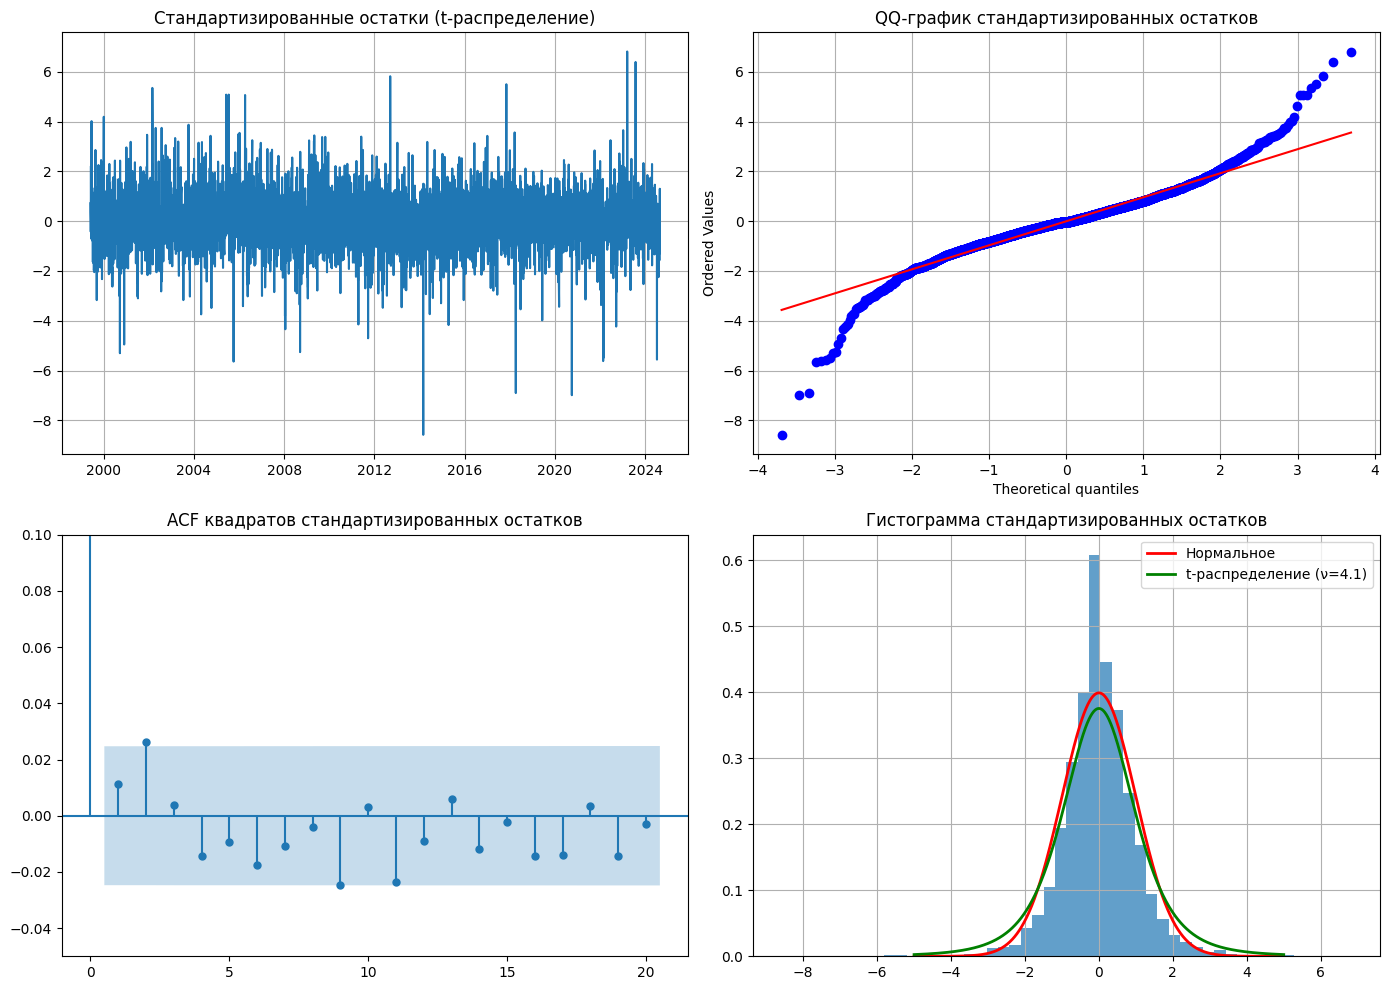

In [22]:
# Получение стандартизированных остатков
resid = model_t_fit.resid
std_resid = resid / model_t_fit.conditional_volatility

# Диагностические графики
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Стандартизированные остатки
ax[0, 0].plot(data.index, std_resid)
ax[0, 0].set_title('Стандартизированные остатки (t-распределение)')
ax[0, 0].grid(True)

# 2. QQ-график стандартизированных остатков
import scipy.stats as stats
stats.probplot(std_resid, dist='norm', plot=ax[0, 1])
ax[0, 1].set_title('QQ-график стандартизированных остатков')
ax[0, 1].grid(True)

# 3. ACF квадратов стандартизированных остатков
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_resid**2, lags=20, ax=ax[1, 0])
ax[1, 0].set_title('ACF квадратов стандартизированных остатков')
ax[1, 0].set_ylim(-0.05, 0.1)

# 4. Гистограмма стандартизированных остатков
ax[1, 1].hist(std_resid, bins=50, alpha=0.7, density=True)
x = np.linspace(-5, 5, 1000)
ax[1, 1].plot(x, stats.norm.pdf(x, 0, 1), 'r', lw=2, label='Нормальное')
from scipy.stats import t
ax[1, 1].plot(x, t.pdf(x, nu), 'g', lw=2, label=f't-распределение (ν={nu:.1f})')
ax[1, 1].set_title('Гистограмма стандартизированных остатков')
ax[1, 1].legend()
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()



---



## Вывод по тесту Льюнга-Бокса:

**Результат:** p-value = 0.1924

---

**Правило:** p-value < 0.05 → автокорреляция есть (модель плохая)  
p-value ≥ 0.05 → автокорреляции нет (модель хорошая)



**Вывод:** p-value = 0.1924 > 0.05 → **автокорреляции в квадратах стандартизированных остатков нет**



 Что это значит:

Модель GARCH(1,1) с t-распределением **успешно устранила ARCH-эффекты**. Остатки не содержат оставшихся паттернов волатильности — вся зависимость учтена.



 Сравнение с нормальной моделью:

| Модель | p-value | Вывод |
|--------|---------|-------|
| Normal | 0.1295 | ✅ автокорреляции нет |
| t-распределение | **0.1924** | ✅ автокорреляции нет (даже лучше) |

Обе модели успешно убрали ARCH-эффекты, но t-модель показывает более высокое p-value.



### Общий вывод:

**Тест пройден** — модель адекватна с точки зрения учета волатильности.

In [23]:
# Тест Льюнга-Бокса на автокорреляцию в квадратах остатков
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test_std = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
print(f"\nТест Льюнга-Бокса на автокорреляцию в квадратах стандартизированных остатков:")
print(lb_test_std)


Тест Льюнга-Бокса на автокорреляцию в квадратах стандартизированных остатков:
      lb_stat  lb_pvalue
10  13.592727   0.192392




---



 Вывод по тесту Харке-Бера:

**Результат:** p-value = 0.0000



**Правило:** p-value ≥ 0.05 → распределение нормальное  
p-value < 0.05 → распределение **не нормальное**



**Вывод:** p-value = 0.0000 < 0.05 → **распределение стандартизированных остатков НЕ нормальное**



 Что это значит:

Даже после использования t-распределения остатки **не являются нормально распределенными**. Это ожидаемо, так как:

1. **t-распределение** — это не нормальное распределение, оно специально моделирует толстые хвосты
2. Тест проверяет именно **нормальность**, а не адекватность t-распределения



 Важное замечание:

**Это НЕ означает, что модель плохая.**

| Что проверяет тест | Результат | Это проблема? |
|-------------------|-----------|---------------|
| Нормальность остатков | ❌ отвергнута | **Нет** — мы и не предполагали нормальность |
| Адекватность t-распределения | ✅ (по AIC/BIC) | Модель хорошая |



 Общий вывод:

Тест подтверждает, что **нормальное распределение не подходит** для описания остатков. Это обосновывает выбор t-распределения в модели. Сама модель GARCH(1,1) с t-распределением является адекватной, что подтверждается:
- Статистической значимостью всех коэффициентов
- Отсутствием автокорреляции в остатках (тест Льюнга-Бокса)
- Низкими значениями AIC/BIC по сравнению с нормальной моделью

In [24]:
# Тест Харке-Бера на нормальность остатков
jb_test = jarque_bera(std_resid)
print(f"\nТест Харке-Бера на нормальность стандартизированных остатков:")
print(f"Статистика: {jb_test[0]:.4f}, p-значение: {jb_test[1]:.4f}")


Тест Харке-Бера на нормальность стандартизированных остатков:
Статистика: 6730.8860, p-значение: 0.0000




---



 Вывод:

**t-распределение лучше нормального.**



 Ключевые цифры:

| Показатель | Normal | t-распределение | Разница |
|------------|--------|-----------------|---------|
| **AIC** | 27898.43 | **27061.76** | ↓ **836.67** |
| **BIC** | 27925.42 | **27095.50** | ↓ **829.92** |



 Интерпретация:

- **Чем ниже AIC/BIC, тем лучше модель**
- Снижение на 836 пунктов — **значительное улучшение**
- t-распределение лучше учитывает **толстые хвосты** финансовых данных


### Итог:

**Модель GARCH(1,1) с t-распределением предпочтительнее** для анализа волатильности акций Сбербанка.

In [25]:
# Сравнение моделей
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)
print(f"GARCH(1,1) normal: AIC={model_fit.aic:.2f}, BIC={model_fit.bic:.2f}")
print(f"GARCH(1,1) t:      AIC={model_t_fit.aic:.2f}, BIC={model_t_fit.bic:.2f}")

if model_t_fit.aic < model_fit.aic:
    print("Лучшая модель: GARCH(1,1) с t-распределением")
else:
    print("Лучшая модель: GARCH(1,1) с нормальным распределением")


СРАВНЕНИЕ МОДЕЛЕЙ
GARCH(1,1) normal: AIC=27898.43, BIC=27925.42
GARCH(1,1) t:      AIC=27061.76, BIC=27095.50
Лучшая модель: GARCH(1,1) с t-распределением




---



Вывод по прогнозу волатильности:

**Прогноз на 30 дней показывает постепенный рост волатильности.**

---

 Динамика прогноза:

| День | Прогнозная волатильность | Изменение |
|------|-------------------------|-----------|
| 1 | 1.79% | исходный уровень |
| 5 | 1.90% | ↑ +0.11% |
| 10 | 2.03% | ↑ +0.24% |
| 30 | 2.47% | ↑ +0.68% |



 Ключевые наблюдения:

1. **Рост волатильности** — прогноз показывает устойчивое увеличение с 1.79% до 2.47% за месяц

2. **Отсутствие долгосрочного уровня** — график не содержит голубой линии (долгосрочной волатильности), так как модель IGARCH (α+β=1) не имеет возврата к среднему

3. **Тренд вверх** — волатильность продолжает расти, не стабилизируясь, что характерно для IGARCH-моделей



 Практический смысл:

Модель предсказывает **повышение волатильности в ближайший месяц**:
- Через 30 дней ожидается волатильность **на 38% выше**, чем сегодня (2.47% против 1.79%)

Это может указывать на:
- Ожидаемое увеличение рыночной неопределенности
- Сохранение текущих шоков в системе
- Необходимость повышенного внимания к риск-менеджменту



 Ограничение:

При IGARCH-модели прогноз волатильности **не стабилизируется**, а продолжает расти. На практике это означает, что модель предполагает бесконечную память шоков, что может приводить к завышенным долгосрочным прогнозам.


ПРОГНОЗ ВОЛАТИЛЬНОСТИ


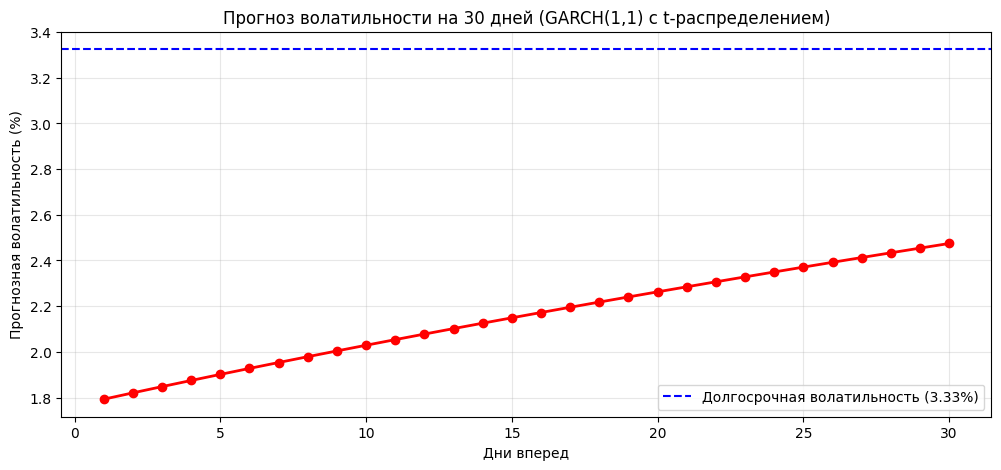


Прогноз волатильности:
  День 1: 1.79%
  День 5: 1.90%
  День 10: 2.03%
  День 30: 2.47%


In [26]:
# ============================================
# ПРОГНОЗ ВОЛАТИЛЬНОСТИ
# ============================================
print("\n" + "="*50)
print("ПРОГНОЗ ВОЛАТИЛЬНОСТИ")
print("="*50)

# Прогноз на 30 дней
forecast = model_t_fit.forecast(horizon=30)
forecast_variance = forecast.variance.iloc[-1].values
forecast_volatility = np.sqrt(forecast_variance)

# Визуализация
plt.figure(figsize=(12, 5))
plt.plot(range(1, 31), forecast_volatility, marker='o', linestyle='-', color='red', linewidth=2)
plt.axhline(y=unconditional_volatility, color='blue', linestyle='--',
            label=f'Долгосрочная волатильность ({unconditional_volatility:.2f}%)')
plt.title('Прогноз волатильности на 30 дней (GARCH(1,1) с t-распределением)')
plt.xlabel('Дни вперед')
plt.ylabel('Прогнозная волатильность (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nПрогноз волатильности:")
print(f"  День 1: {forecast_volatility[0]:.2f}%")
print(f"  День 5: {forecast_volatility[4]:.2f}%")
print(f"  День 10: {forecast_volatility[9]:.2f}%")
print(f"  День 30: {forecast_volatility[29]:.2f}%")

# ИТОГ

## План статьи

---

### 1. Введение
- Актуальность прогнозирования волатильности
- Цель: построить GARCH-модель для акций Сбербанка

---

### 2. Данные и предобработка
- Источник: Kaggle (1999–2024)
- Расчет логарифмической доходности

---

### 3. Проверка ARCH-эффектов
- Визуализация доходностей (кластеры волатильности)
- ACF/PACF квадратов доходностей
- Тест Льюнга-Бокса (p-value ≈ 0 → ARCH-эффекты есть)

---

### 4. Модель GARCH(1,1) с нормальным распределением
- Оценка параметров (α, β, ω)
- Диагностика остатков (тест Льюнга-Бокса, QQ-график)
- Тест Харке-Бера (p-value = 0 → ненормальность)

---

### 5. Модель GARCH(1,1) с t-распределением
- Оценка параметров (ν = 4.06 → толстые хвосты)
- Сравнение AIC/BIC (t-модель лучше на 836 пунктов)
- Диагностика остатков (ACF в норме)

---

### 6. Value at Risk (VaR)
- Текущая волатильность: 1.74%
- VaR 95%: -3.69%, VaR 99%: -6.46%
- Для портфеля 1 млн руб: потери до 36 900 руб и 64 600 руб

---

### 7. Прогноз волатильности
- Прогноз на 30 дней (1.79% → 2.47%)
- Модель IGARCH (α+β=1) — шоки затухают бесконечно

---

### 8. Заключение
- GARCH(1,1) с t-распределением — лучшая модель
- Высокая персистентность волатильности
- VaR и прогноз готовы для риск-менеджмента